## 1. Install & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('Library berhasil di-import!')

Library berhasil di-import!


## 2. Load Data Preprocessed

In [2]:
df = pd.read_csv('../data/data_preprocessed.csv')
print(f'Shape data: {df.shape}')
print(f"Distribusi label:\n{df['sentiment'].value_counts()}")
df.head()

Shape data: (1188, 6)
Distribusi label:
sentiment
Negatif    761
Netral     345
Positif     82
Name: count, dtype: int64


,text_processed,sentiment,label,score,text_length,word_count
0,osang asing osang asing lebih baik makan oseng...,Negatif,0,-1,84,17
1,lupa apa pikun,Negatif,0,-1,16,4
2,tempo itu sejak sidney jones itu udah jelas bg...,Negatif,0,-1,211,32
3,inilah yang terjadi kalau segala sesuatu disel...,Netral,1,0,183,26
4,cangkeme owo efisiensi tapi kelakuane borosisasi,Netral,1,0,48,6


## 3. Setup PyCaret NLP

In [15]:
from pycaret.classification import *

# Setup PyCaret
clf = setup(
    data=df,
    target='sentiment',
    text_features=['text_processed'],      # kolom teks
    numeric_features=['score', 'text_length', 'word_count'],
    ignore_features=['label'],
    fix_imbalance=False,                   # hindari mismatch saat finalize_model pada fitur teks
    train_size=0.8,
    session_id=42,
    n_jobs=-1,
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,sentiment
2,Target type,Multiclass
3,Target mapping,"Negatif: 0, Netral: 1, Positif: 2"
4,Original data shape,"(1188, 6)"
5,Transformed data shape,"(1188, 3926)"
6,Transformed train set shape,"(950, 3926)"
7,Transformed test set shape,"(238, 3926)"
8,Ignore features,1
9,Numeric features,3


## 4. Benchmark 3 Algoritma ML

In [16]:
# Benchmark hanya 3 model: Logistic Regression, Random Forest, Naive Bayes
print('='*60)
print('BENCHMARK 3 ALGORITMA ML')
print('1. Logistic Regression (lr)')
print('2. Random Forest (rf)')
print('3. Naive Bayes (nb)')
print('='*60)

top3 = compare_models(
    include=['lr', 'rf', 'nb'],
    sort='F1',
    n_select=3,
    cross_validation=True,
    fold=5
)

BENCHMARK 3 ALGORITMA ML
1. Logistic Regression (lr)
2. Random Forest (rf)
3. Naive Bayes (nb)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9989,0.0000,0.9989,0.9990,0.9990,0.9979,0.9979,1.8800
rf,Random Forest Classifier,0.9411,0.9976,0.9411,0.9469,0.9268,0.8785,0.8831,0.7420
nb,Naive Bayes,0.7221,0.6772,0.7221,0.7843,0.6874,0.3685,0.4169,0.5620


In [17]:
# Tampilkan hasil perbandingan
results_df = pull()
print('\nHasil Benchmark 5-Fold Cross Validation:')

# Kompatibel untuk variasi nama kolom antar versi PyCaret
column_alias = {
    'Precision': ['Prec. Macro', 'Precision Macro', 'Prec.', 'Precision'],
    'Recall': ['Recall Macro', 'Recall']
}

selected_cols = ['Model', 'Accuracy']
for _, candidates in column_alias.items():
    selected_cols.append(next((c for c in candidates if c in results_df.columns), None))
selected_cols += ['F1', 'Kappa']

selected_cols = [c for c in selected_cols if c is not None and c in results_df.columns]
print(results_df[selected_cols].to_string(index=False))


Hasil Benchmark 5-Fold Cross Validation:
                   Model  Accuracy  Prec.  Recall     F1  Kappa
     Logistic Regression    0.9989 0.9990  0.9989 0.9990 0.9979
Random Forest Classifier    0.9411 0.9469  0.9411 0.9268 0.8785
             Naive Bayes    0.7221 0.7843  0.7221 0.6874 0.3685


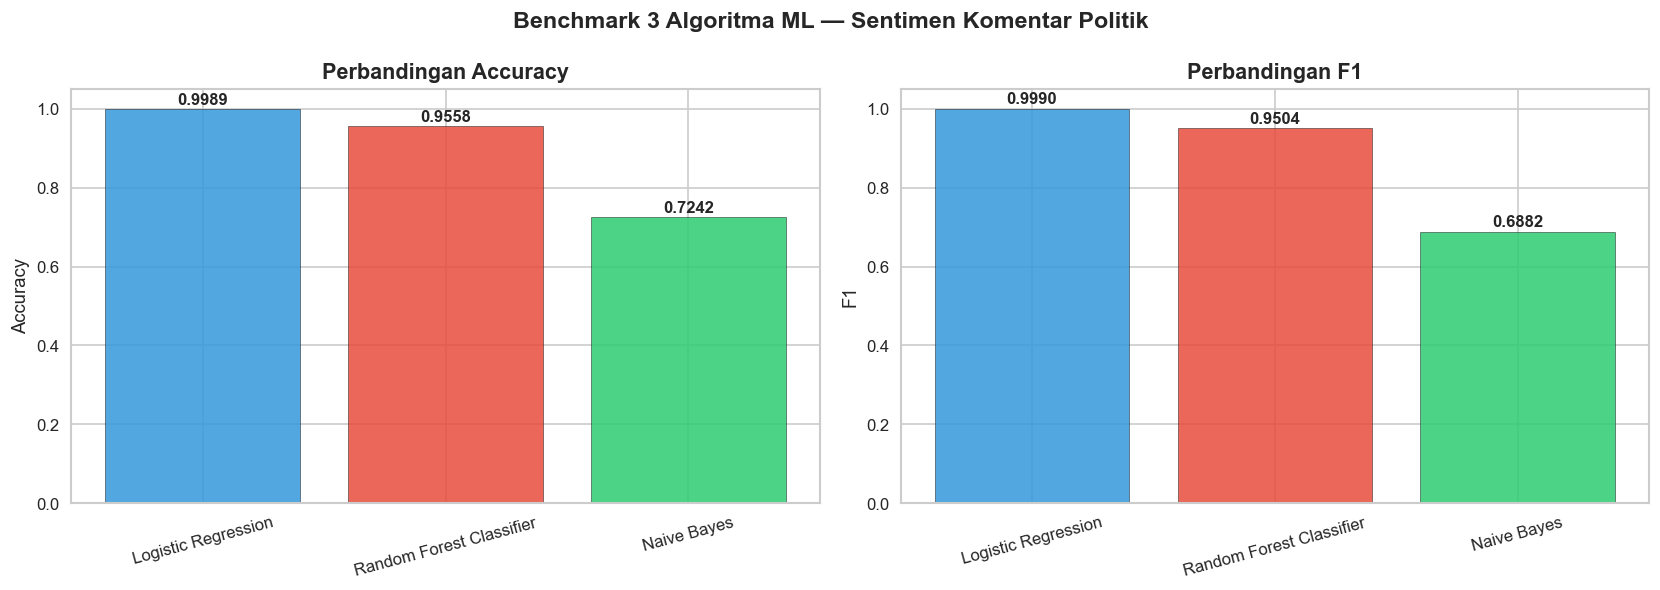

In [8]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = results_df['Model'].tolist()
metrics = ['Accuracy', 'F1']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, metric in zip(axes, metrics):
    values = results_df[metric].tolist()
    bars = ax.bar(model_names, values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'Perbandingan {metric}', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Benchmark 3 Algoritma ML — Sentimen Komentar Politik', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('../assets', exist_ok=True)
plt.savefig('../assets/benchmark_ml.png', bbox_inches='tight')
plt.show()

## 5. Pilih & Evaluasi Model Terbaik

In [18]:
# Model terbaik berdasarkan F1
best_model_name = results_df.iloc[0]['Model']
print(f'✅ Model terbaik berdasarkan F1: {best_model_name}')
print(f"   Accuracy : {results_df.iloc[0]['Accuracy']:.4f}")
print(f"   F1 Macro : {results_df.iloc[0]['F1']:.4f}")

best_model = top3[0]  # model pertama adalah yang terbaik
print(f'\nModel object: {best_model}')

✅ Model terbaik berdasarkan F1: Logistic Regression
   Accuracy : 0.9989
   F1 Macro : 0.9990

Model object: LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


In [10]:
# Confusion Matrix
print('=== Confusion Matrix ===')
plot_model(best_model, plot='confusion_matrix', save=True)

=== Confusion Matrix ===


'Confusion Matrix.png'

In [11]:
# Classification Report
print('=== Classification Report ===')
plot_model(best_model, plot='class_report', save=True)

=== Classification Report ===


'Class Report.png'

In [12]:
# Feature Importance (jika didukung)
try:
    plot_model(best_model, plot='feature', save=True)
    print('Feature importance plot berhasil.')
except Exception as e:
    print(f'Feature importance tidak tersedia untuk model ini: {e}')

Feature importance plot berhasil.


## 6. Finalisasi Model

In [19]:
# Finalisasi: retrain pada seluruh data
final_model = finalize_model(best_model)
print('✅ Model berhasil difinalisasi dengan seluruh data training.')

✅ Model berhasil difinalisasi dengan seluruh data training.


## 7. Evaluasi pada Data Test

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

# Prediksi pada test set
predictions = predict_model(best_model)
print('Prediksi pada test set:')
print(predictions[['text_processed', 'sentiment', 'prediction_label', 'prediction_score']].head(10))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Prediksi pada test set:
                                        text_processed sentiment  \
57   koar koar antek asing eh tapi bayar miliaran b...   Negatif   
618                    kasian rakyat indonesia gua mah    Netral   
589             pemerintah ibarat maling teriak maling   Negatif   
598  begitu uu ini kalau nantinya disahkan pertama ...   Negatif   
756              say the words wok antek antek asenngg   Negatif   
579  rakyat ada yg di tuduh antek asing padahal bos...   Negatif   
940              antek asing kemarin vat mau aja wkwkw   Negatif   
60   kita harus percaya adanya antek asing siapa yg...   Negatif   
512  sejak lama prabowo secara konsisten membangun ...   Negatif   
991  jokowi dan team solo adalah antek asing china rrc   Negatif   

    prediction_label  prediction_score  
57           Negatif            1.0000  
618           Netral            0.9564  
589          Negatif            1.0000  
598          Negatif            0.9598  
756          Negatif  

In [21]:
# Hitung metrik
y_true = predictions['sentiment']
y_pred = predictions['prediction_label']

print('\n=== CLASSIFICATION REPORT (Test Set) ===')
print(classification_report(y_true, y_pred, target_names=['Negatif', 'Netral', 'Positif']))


=== CLASSIFICATION REPORT (Test Set) ===
              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00       153
      Netral       1.00      1.00      1.00        69
     Positif       1.00      1.00      1.00        16

    accuracy                           1.00       238
   macro avg       1.00      1.00      1.00       238
weighted avg       1.00      1.00      1.00       238



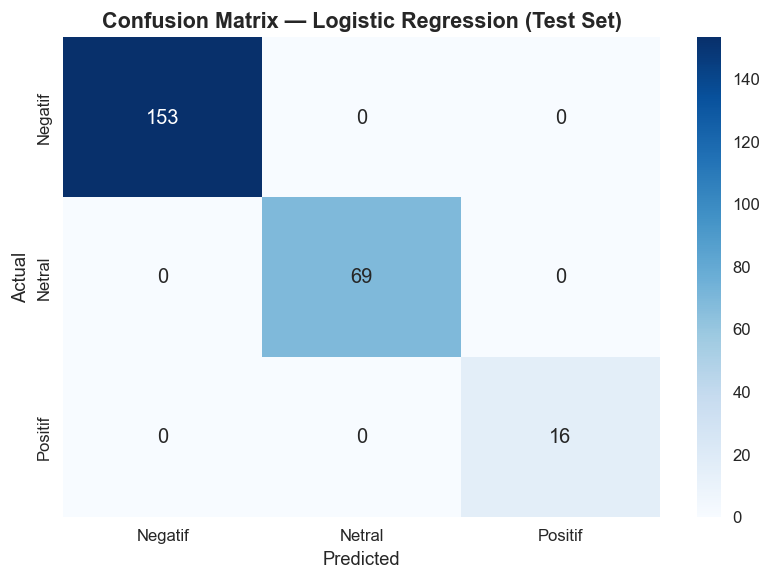

In [22]:
# Confusion matrix manual
cm = confusion_matrix(y_true, y_pred, labels=['Negatif', 'Netral', 'Positif'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'], ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name} (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../assets/confusion_matrix_test.png', bbox_inches='tight')
plt.show()

## 8. Simpan Model untuk Deployment

In [23]:
os.makedirs('../model_ml', exist_ok=True)

# Simpan model PyCaret (format pickle)
save_model(final_model, '../model_ml/sentiment_ml_model')

# Simpan juga info model
model_info = {
    'model_name': best_model_name,
    'accuracy': float(results_df.iloc[0]['Accuracy']),
    'f1_macro': float(results_df.iloc[0]['F1']),
    'label_map': {'Negatif': 0, 'Netral': 1, 'Positif': 2},
    'classes': ['Negatif', 'Netral', 'Positif']
}
joblib.dump(model_info, '../model_ml/model_info.pkl')

print('✅ Model berhasil disimpan!')
print('File yang disimpan:')
print('  - model_ml/sentiment_ml_model.pkl')
print('  - model_ml/model_info.pkl')

Transformation Pipeline and Model Successfully Saved
✅ Model berhasil disimpan!
File yang disimpan:
  - model_ml/sentiment_ml_model.pkl
  - model_ml/model_info.pkl


## 9. Uji Coba Prediksi Manual

In [24]:
# Load model dan coba prediksi
loaded_model = load_model('../model_ml/sentiment_ml_model')

contoh_teks = [
    {'text_processed': 'pemerintah ini sangat buruk tidak ada gunanya',
     'score': -3, 'text_length': 42, 'word_count': 7},
    {'text_processed': 'bagus sekali kerjanya mantap',
     'score': 2, 'text_length': 28, 'word_count': 4},
    {'text_processed': 'oke oke saja biasa',
     'score': 0, 'text_length': 18, 'word_count': 4},
]

test_df = pd.DataFrame(contoh_teks)
hasil = predict_model(loaded_model, data=test_df)
print('\nHasil prediksi:')
for i, row in hasil.iterrows():
    print(f'Teks    : {row["text_processed"]}')
    print(f'Prediksi: {row["prediction_label"]} (confidence: {row["prediction_score"]:.2f})')
    print()

Transformation Pipeline and Model Successfully Loaded



Hasil prediksi:
Teks    : pemerintah ini sangat buruk tidak ada gunanya
Prediksi: Negatif (confidence: 1.00)

Teks    : bagus sekali kerjanya mantap
Prediksi: Positif (confidence: 1.00)

Teks    : oke oke saja biasa
Prediksi: Netral (confidence: 0.96)

